## QFT resource estimation pipeline

Full QRE pipeline for the Quantum Fourier Transform: logical gate counts from
Qualtran, small-instance verification, a bitsize sweep, QREF export, Bartiq
symbolic compilation, and a surface-code physical model.

Standalone — it uses Qualtran/QREF/Bartiq directly rather than the `qrepro`
API. For the reproductions this repository asserts, see
`reference_reproductions.ipynb`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import yaml
from bartiq import compile_routine, evaluate
from qref import SchemaV1
from qualtran.bloqs.qft.approximate_qft import ApproximateQFT
from qualtran.bloqs.qft.qft_text_book import QFTTextBook
from qualtran.resource_counting import QECGatesCost, QubitCount, get_cost_value
from qualtran.surface_code import (
    AlgorithmSummary,
    CCZ2TFactory,
    PhysicalCostModel,
    PhysicalParameters,
    QECScheme,
    SimpleDataBlock,
)

### 1. Logical costs

`QECGatesCost()` walks the decomposition tree and tallies And/CCZ gates,
rotations, T-gates and Cliffords separately. `total_t_and_ccz_count()` resolves
rotations into T-gates via Clifford+T synthesis (≈11 T per rotation at
Qualtran's default precision); the T-equivalent count is `n_t + 4·n_ccz`.

In [2]:
# Defining the primitive
qft = QFTTextBook(bitsize=32)

# Extracting logical cost
cost = get_cost_value(qft, QECGatesCost())

print("QFT(32) logical costs:")
print(cost)
print()
print("Breakdown:")
print(f"  T-gates:    {cost.t}")
print(f"  And (≈CCZ): {cost.and_bloq}")
print(f"  Rotations:  {cost.rotation}")
print(f"  Cliffords:  {cost.clifford}")
print(f"  Measure:    {cost.measurement}")

QFT(32) logical costs:
t: 30, and_bloq: 496, clifford: 575, rotation: 435, measurement: 496

Breakdown:
  T-gates:    30
  And (≈CCZ): 496
  Rotations:  435
  Cliffords:  575
  Measure:    496


In [3]:
# Qubit count
n_qubits = get_cost_value(qft, QubitCount())
print(f"QFT(32) qubit count: {n_qubits}")

QFT(32) qubit count: 33


### 2. Small-instance verification

Contract QFT(3) to its unitary, check unitarity, and print the Cirq circuit.

In [4]:
# Verify small instances
small_qft = QFTTextBook(bitsize=3)

# Tensor contraction - get the unitary matrix
uni = small_qft.tensor_contract()
N = 2**3
print(f"Unitary shape: {uni.shape}")
print(f"Is unitary: {np.allclose(uni @ uni.conj().T, np.eye(N))}")

# Cirq circuit
composite = small_qft.decompose_bloq()
circuit = composite.to_cirq_circuit()
print(f"Cirq circuit depth: {len(circuit)}")
print(f"\nCircuit:\n{circuit}")

Unitary shape: (8, 8)
Is unitary: True
Cirq circuit depth: 6

Circuit:
q0: ───H───Z^0.5/2───────Z^0.5/4───────×───
           │             │             │
q1: ───────@─────────H───Z^0.5/2───────┼───
                         │             │
q2: ─────────────────────@─────────H───×───


### 3. Bitsize sweep

T-equivalent counts and qubit counts for textbook and approximate QFT over
n ∈ {8, 16, 32, 64, 128}. The approximate variant truncates small-angle
rotations, so the ratio between the two is rotation-synthesis cost.

In [5]:
bitsizes = [8, 16, 32, 64, 128]
results = []

for n in bitsizes:
    # Textbook QFT
    cost_tb = get_cost_value(QFTTextBook(bitsize=n), QECGatesCost())
    tb_counts = cost_tb.total_t_and_ccz_count()  # returns {'n_t': ..., 'n_ccz': ...}
    tb_total = tb_counts["n_t"] + 4 * tb_counts["n_ccz"]
    tb_qubits = get_cost_value(QFTTextBook(bitsize=n), QubitCount())

    # Approximate QFT (phase_bitsize = n//2)
    cost_ap = get_cost_value(
        ApproximateQFT(bitsize=n, phase_bitsize=n // 2), QECGatesCost()
    )
    ap_counts = cost_ap.total_t_and_ccz_count()
    ap_total = ap_counts["n_t"] + 4 * ap_counts["n_ccz"]

    results.append(
        {
            "n": n,
            "tb_t": tb_counts["n_t"],
            "tb_ccz": tb_counts["n_ccz"],
            "tb_total": tb_total,
            "tb_rotations": cost_tb.rotation,
            "tb_qubits": tb_qubits,
            "ap_t": ap_counts["n_t"],
            "ap_ccz": ap_counts["n_ccz"],
            "ap_total": ap_total,
        }
    )

    ratio = tb_total / ap_total if ap_total > 0 else float("inf")
    print(
        f"n={n:>4}  TB: {tb_total:>6} T-equiv  AP: {ap_total:>6} T-equiv  ratio: {ratio:.1f}x"
    )

n=   8  TB:    283 T-equiv  AP:     88 T-equiv  ratio: 3.2x
n=  16  TB:   1495 T-equiv  AP:    552 T-equiv  ratio: 2.7x


n=  32  TB:   6799 T-equiv  AP:   2632 T-equiv  ratio: 2.6x


n=  64  TB:  25627 T-equiv  AP:  11400 T-equiv  ratio: 2.2x


n= 128  TB:  76187 T-equiv  AP:  47368 T-equiv  ratio: 1.6x


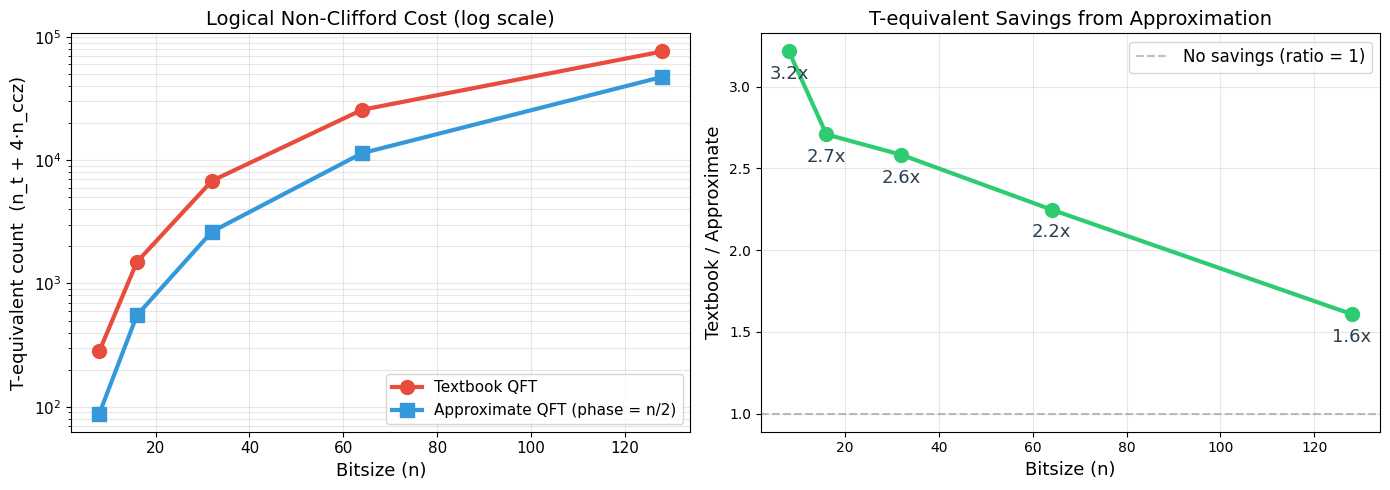

In [6]:
# Textbook vs Approximate QFT: T-equivalent count
ns = [r["n"] for r in results]
tb_totals = [r["tb_total"] for r in results]
ap_totals = [r["ap_total"] for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: T-equivalent count, log scale.
ax1.semilogy(
    ns,
    tb_totals,
    "o-",
    color="#e74c3c",
    linewidth=3,
    markersize=10,
    label="Textbook QFT",
)
ax1.semilogy(
    ns,
    ap_totals,
    "s-",
    color="#3498db",
    linewidth=3,
    markersize=10,
    label="Approximate QFT (phase = n/2)",
)
ax1.set_xlabel("Bitsize (n)", fontsize=13)
ax1.set_ylabel("T-equivalent count  (n_t + 4·n_ccz)", fontsize=13)
ax1.set_title("Logical Non-Clifford Cost (log scale)", fontsize=14)
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(True, alpha=0.3, which="both")
ax1.tick_params(axis="both", labelsize=11)

# Right: textbook / approximate ratio.
ratios = [tb / ap if ap > 0 else 0 for tb, ap in zip(tb_totals, ap_totals)]
valid_ns = [n for n, r in zip(ns, ratios) if r > 0]
valid_ratios = [r for r in ratios if r > 0]
ax2.plot(valid_ns, valid_ratios, "o-", color="#2ecc71", linewidth=3, markersize=10)
ax2.set_xlabel("Bitsize (n)", fontsize=13)
ax2.set_ylabel("Textbook / Approximate", fontsize=13)
ax2.set_title("T-equivalent Savings from Approximation", fontsize=14)
ax2.axhline(
    y=1, color="gray", linestyle="--", alpha=0.5, label="No savings (ratio = 1)"
)
ax2.legend(fontsize=12, loc="upper right")
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis="both", labelsize=10)
# Annotate each point with the ratio value
for x, y in zip(valid_ns, valid_ratios):
    ax2.annotate(
        f"{y:.1f}x",
        (x, y),
        textcoords="offset points",
        xytext=(0, -20),
        ha="center",
        fontsize=13,
        color="#2c3e50",
    )

plt.tight_layout()
plt.savefig("outputs/chart_qft_textbook_vs_approx.png", dpi=150, bbox_inches="tight")
plt.show()

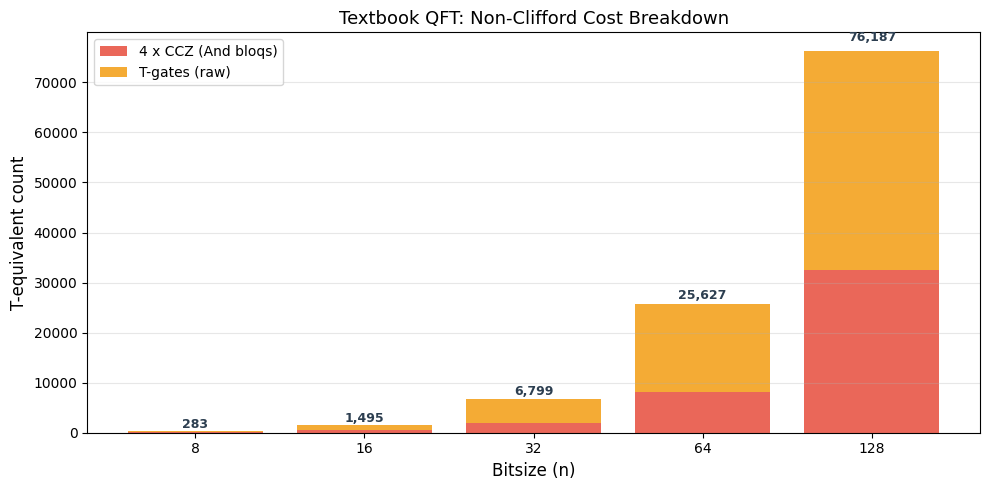

In [7]:
# Non-Clifford cost split: 4 x CCZ vs raw T-gates.
fig, ax = plt.subplots(figsize=(10, 5))

tb_ts = [r["tb_t"] for r in results]
tb_ccz4 = [4 * r["tb_ccz"] for r in results]  # each CCZ = 4 T-gates

x = range(len(ns))
bars_ccz = ax.bar(x, tb_ccz4, label="4 x CCZ (And bloqs)", color="#e74c3c", alpha=0.85)
bars_t = ax.bar(
    x, tb_ts, bottom=tb_ccz4, label="T-gates (raw)", color="#f39c12", alpha=0.85
)

ax.set_xticks(list(x))
ax.set_xticklabels([str(n) for n in ns])
ax.set_xlabel("Bitsize (n)", fontsize=12)
ax.set_ylabel("T-equivalent count", fontsize=12)
ax.set_title("Textbook QFT: Non-Clifford Cost Breakdown", fontsize=13)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3, axis="y")
ax.tick_params(axis="both", labelsize=10)

# Label total on top of each bar
for i, (ccz, t) in enumerate(zip(tb_ccz4, tb_ts)):
    total = ccz + t
    ax.text(
        i,
        total + total * 0.02,
        f"{total:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="#2c3e50",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("outputs/chart_qft_cost_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. QREF export

[QREF](https://github.com/PsiQ/qref) represents FTQC algorithms as hierarchical
cost DAGs; [Bartiq](https://github.com/PsiQ/bartiq) propagates symbolic cost
expressions through them. Both are independent of Qualtran. The next cell packs
the QFT(32) costs into a QREF v1 program and writes it to
`outputs/qft_textbook.qref.yaml`.

In [8]:
# Build a QREF program from the QFT(32) costs.
qft32_cost = get_cost_value(QFTTextBook(bitsize=32), QECGatesCost())
qft32_qubits = get_cost_value(QFTTextBook(bitsize=32), QubitCount())

# total_t_and_ccz_count() folds rotation synthesis into the T_gates resource.
qft32_counts = qft32_cost.total_t_and_ccz_count()
qft32_t_equiv = qft32_counts["n_t"] + 4 * qft32_counts["n_ccz"]

program = SchemaV1(
    version="v1",
    program={
        "name": "qft_textbook",
        "ports": [
            {"name": "in", "direction": "input", "size": 32},
            {"name": "out", "direction": "output", "size": 32},
        ],
        "resources": [
            {"name": "T_gates", "type": "additive", "value": qft32_t_equiv},
            {"name": "rotations", "type": "additive", "value": qft32_cost.rotation},
            {"name": "cliffords", "type": "additive", "value": qft32_cost.clifford},
            {"name": "n_qubits", "type": "additive", "value": int(qft32_qubits)},
        ],
        "children": [],
        "connections": [],
    },
)

# Save as YAML
qref_path = "outputs/qft_textbook.qref.yaml"
with open(qref_path, "w") as f:
    yaml.dump(program.model_dump(), f, default_flow_style=False)

print(f"QREF program saved to {qref_path}")
print()
print(yaml.dump(program.model_dump(), default_flow_style=False))

QREF program saved to outputs/qft_textbook.qref.yaml

program:
  children: []
  connections: []
  input_params: []
  linked_params: []
  local_variables: {}
  meta: {}
  name: qft_textbook
  ports:
  - direction: input
    name: in
    size: 32
  - direction: output
    name: out
    size: 32
  repetition: null
  resources:
  - name: T_gates
    type: additive
    value: 6799
  - name: cliffords
    type: additive
    value: 575
  - name: n_qubits
    type: additive
    value: 33
  - name: rotations
    type: additive
    value: 435
  type: null
version: v1



### 5. Bartiq compilation

Compile the concrete QREF program (a round-trip check against section 1), then
compile a parametric version whose T-cost is the symbolic expression
`n*(n-1)/2 * 13` and evaluate it at several n.

That expression is an approximation: the exact T-cost depends on
rotation-synthesis internals held by Qualtran, so the values do not match the
concrete counts. Bartiq propagates such expressions from leaves to root in
hierarchical programs.

In [9]:
# Compile the concrete QREF program
compilation_result = compile_routine(program)
routine = compilation_result.routine

print("Compiled routine resources (concrete, matches section 1):")
for name, res in routine.resources.items():
    print(f"  {name}: {res.value}")

Compiled routine resources (concrete, matches section 1):
  T_gates: 6799
  cliffords: 575
  n_qubits: 33
  rotations: 435


In [10]:
# Parametric version with an approximate symbolic cost formula.

parametric_program = SchemaV1(
    version="v1",
    program={
        "name": "qft_parametric",
        "ports": [
            {"name": "in", "direction": "input", "size": "n"},
            {"name": "out", "direction": "output", "size": "n"},
        ],
        "input_params": ["n"],
        "resources": [
            {"name": "T_gates", "type": "additive", "value": "n*(n-1)/2 * 13"},
            {"name": "n_qubits", "type": "additive", "value": "n + 1"},
        ],
        "children": [],
        "connections": [],
    },
)

compilation_result_p = compile_routine(parametric_program)
routine_p = compilation_result_p.routine

print("Parametric evaluation (approximate formula):")
for n_val in [16, 32, 64, 128]:
    eval_result = evaluate(routine_p, assignments={"n": n_val})
    resources = eval_result.routine.resources
    print(
        f"  n={n_val:>4}  T_gates={resources['T_gates'].value:>8}  n_qubits={resources['n_qubits'].value}"
    )

Parametric evaluation (approximate formula):
  n=  16  T_gates=    1560  n_qubits=17
  n=  32  T_gates=    6448  n_qubits=33
  n=  64  T_gates=   26208  n_qubits=65
  n= 128  T_gates=  105664  n_qubits=129


### 6. Physical layer

`AlgorithmSummary.from_bloq()` extracts logical costs from a bloq and
`PhysicalCostModel` applies the surface-code hardware assumptions, giving
physical qubits, runtime, cycle count and failure probability at d=17 and
p_err=1e-3.

In [11]:
qft32 = QFTTextBook(bitsize=32)
summary = AlgorithmSummary.from_bloq(qft32)

print("Algorithm summary:")
print(f"  Logical gates    : {summary.n_logical_gates}")
print(f"  Algo qubits      : {summary.n_algo_qubits}")
# from_bloq reports rotation_layers as None for some bloqs; the physical model
# uses n_logical_gates directly.
print(f"  Rotation layers  : {summary.n_rotation_layers}")

# Physical-layer assumptions
phys = PhysicalParameters(physical_error=1e-3, cycle_time_us=1.0)
qec = QECScheme(error_rate_scaler=0.03, error_rate_threshold=0.01)
factory = CCZ2TFactory()
data_block = SimpleDataBlock(data_d=17, routing_overhead=0.5)

model = PhysicalCostModel(
    physical_params=phys,
    data_block=data_block,
    factory=factory,
    qec_scheme=qec,
)

print()
print("Physical cost estimate (surface-code, d=17, p_err=1e-3):")
print(f"  Physical qubits  : {model.n_phys_qubits(summary):,}")
print(f"  Runtime (hours)  : {model.duration_hr(summary):.4f}")
print(f"  Cycles           : {model.n_cycles(summary):,}")
print(f"  Error            : {model.error(summary):.2e}")

Algorithm summary:
  Logical gates    : t: 30, and_bloq: 496, clifford: 575, rotation: 435, measurement: 496
  Algo qubits      : 33
  Rotation layers  : None

Physical cost estimate (surface-code, d=17, p_err=1e-3):
  Physical qubits  : 176,804
  Runtime (hours)  : 0.0002
  Cycles           : 569,780
  Error            : 8.55e-04
